# <span style='color:orange'>Paludisme en Afrique: Analyse simple et visualisation</span>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('malaria.csv')

In [3]:
df.sample(2)

,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry
124,Equatorial Guinea,2009,GNQ,351.29,14184.0,NaN,NaN,NaN,NaN,NaN,...,7.16,59.29,33.21,73.74,63.01,53.65,68.20,1.650801,10.267895,POINT (1.650801 10.267895)
263,Sudan,2011,SDN,29.97,506806.0,NaN,NaN,NaN,NaN,NaN,...,2.66,53.28,45.74,68.44,29.57,18.61,51.62,12.862807,30.217636,POINT (12.862807 30.217636)


In [4]:
def sous_region_afrique(pays):
    pays = pays.strip()

    regions = {
        'North Africa': ['Algeria', 'Egypt, Arab Rep.', 'Libya', 'Morocco', 'Sudan', 'Tunisia'],
        'West Africa': ['Benin', 'Burkina Faso', 'Cabo Verde', "Cote d'Ivoire", 'Gambia, The', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Liberia','Mauritania' ,'Mali', 'Niger', 'Nigeria', 'Senegal', 'Sierra Leone', 'Togo'],
        'Central Africa': ['Angola', 'Cameroon', 'Central African Republic', 'Chad', 'Congo, Rep.', 'Congo, Dem. Rep.', 'Equatorial Guinea', 'Gabon', 'Sao Tome and Principe'],
        'East Africa': ['Burundi', 'Comoros', 'Djibouti', 'Eritrea', 'Ethiopia', 'Kenya', 'Madagascar', 'Malawi', 'Mauritius', 'Mozambique', 'Rwanda', 'Seychelles', 'Somalia', 'South Sudan', 'Tanzania', 'Uganda'],
        'Southern Africa': ['Botswana', 'Lesotho', 'Namibia', 'South Africa', 'Eswatini', 'Zambia', 'Zimbabwe']
    }

    for region, pays_list in regions.items():
        if pays in pays_list:
            return region

    return 'Zone non reconnue'

df['Sous region'] = df['Country Name'].apply(sous_region_afrique)


In [5]:
df.sample(8)

,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry,Sous region
87,Mauritius,2008,MUS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,99.64,99.48,99.86,93.39,92.57,94.54,-20.348404,57.552152,POINT (-20.348404 57.552152),East Africa
487,Angola,2016,AGO,219.99,3794253.0,21.7,18.1,20.0,NaN,NaN,...,55.08,27.08,70.74,48.63,22.31,63.34,-11.202692,17.873887,POINT (-11.202692 17.873887),Central Africa
348,Guinea-Bissau,2013,GNB,113.39,54584.0,NaN,NaN,NaN,NaN,NaN,...,64.13,51.30,82.35,18.64,7.60,34.33,11.772300,-15.169600,POINT (11.7723 -15.1696),West Africa
296,Lesotho,2012,LSO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,68.16,60.70,89.72,33.72,32.60,36.97,-29.609988,28.233608,POINT (-29.609988 28.233608),Southern Africa
33,Mauritius,2007,MUS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,99.59,99.41,99.84,92.97,92.05,94.25,-20.348404,57.552152,POINT (-20.348404 57.552152),East Africa
341,Eritrea,2013,ERI,15.03,21317.0,NaN,NaN,NaN,NaN,NaN,...,50.71,27.80,89.74,11.64,5.56,21.99,15.179384,39.782334,POINT (15.179384 39.782334),East Africa
312,Seychelles,2012,SYC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,96.23,NaN,NaN,99.24,NaN,NaN,-4.679574,55.491977,POINT (-4.679574 55.491977),East Africa
426,Tanzania,2014,TZA,118.94,680442.0,NaN,NaN,NaN,NaN,NaN,...,51.12,37.48,81.62,25.35,20.09,37.11,-6.369028,34.888822,POINT (-6.369028 34.888822),East Africa


In [6]:
col=['Incidence of malaria (per 1,000 population at risk)',
       'Malaria cases reported',
       'Use of insecticide-treated bed nets (% of under-5 population)',
       'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)',
       'Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)',
       'People using safely managed drinking water services (% of population)',
       'People using safely managed drinking water services, rural (% of rural population)',
       'People using safely managed drinking water services, urban (% of urban population)',
       'People using safely managed sanitation services (% of population)',
       'People using safely managed sanitation services, rural (% of rural population)',
       'People using safely managed sanitation services, urban  (% of urban population)',
       'Rural population (% of total population)',
       'Rural population growth (annual %)',
       'Urban population (% of total population)',
       'Urban population growth (annual %)',
       'People using at least basic drinking water services (% of population)',
       'People using at least basic drinking water services, rural (% of rural population)',
       'People using at least basic drinking water services, urban (% of urban population)',
       'People using at least basic sanitation services (% of population)',
       'People using at least basic sanitation services, rural (% of rural population)',
       'People using at least basic sanitation services, urban  (% of urban population)',
       'latitude', 'longitude']
# Calcul de la médiane par Sous-region pour toutes les colonnes que tu veux
median_per_region = df.groupby('Sous region')[col].median()

# Fonction pour remplir les NaN avec la médiane par région pour UNE colonne donnée
def remplir_valeur(row, colonne):
    if pd.isna(row[colonne]):
        return median_per_region.loc[row['Sous region'], colonne]
    else:
        return row[colonne]

for colon in col:
    df[colon] = df.apply(lambda row: remplir_valeur(row, colon), axis=1)
    for col in df.columns:
        if df[col].isnull().any():
            most_frequent = df[col].mode()[0]  # Get the most frequent value
            df[col].fillna(most_frequent, inplace=True)


df.info()


C:\Users\acer\AppData\Local\Temp\ipykernel_11964\1559854913.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(most_frequent, inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 28 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Country Name                                                                             594 non-null    object 
 1   Year                                                                                     594 non-null    int64  
 2   Country Code                                                                             594 non-null    object 
 3   Incidence of malaria (per 1,000 population at risk)                                      594 non-null    float64
 4   Malaria cases reported                                                                   594 non-null    float64
 5   Use of insecticide-treated bed nets (% of under-5 population)   

In [7]:

# Fonction pour extraire manuellement les coordonnées
def extract_coordinates_manually(point_str):
    # Supprimer "POINT (" et ")"
    coordinates_str = point_str.replace("POINT (", "").replace(")", "")
    
    # Séparer les coordonnées X et Y
    x_str, y_str = coordinates_str.split()
    
    # Convertir en float
    x = float(x_str)
    y = float(y_str)
    
    return x, y

# Appliquer la fonction pour extraire les coordonnées et créer les colonnes X et Y
df[['Geometry_X', 'Geometry_Y']] = pd.DataFrame(df['geometry'].apply(extract_coordinates_manually).to_list(), index=df.index)

# Afficher le DataFrame
df.sample(2)

,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,"People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry,Sous region,Geometry_X,Geometry_Y
566,Lesotho,2017,LSO,2.740,0.0,26.0,38.4,5.7,5.77,39.93,...,92.96,42.75,42.77,42.72,-29.609988,28.233608,POINT (-29.609988 28.233608),Southern Africa,-29.609988,28.233608
33,Mauritius,2007,MUS,113.955,0.0,26.0,38.4,5.7,5.77,39.93,...,99.84,92.97,92.05,94.25,-20.348404,57.552152,POINT (-20.348404 57.552152),East Africa,-20.348404,57.552152


In [8]:
df["Pourcetage de population atteint"]=df['Incidence of malaria (per 1,000 population at risk)']/10

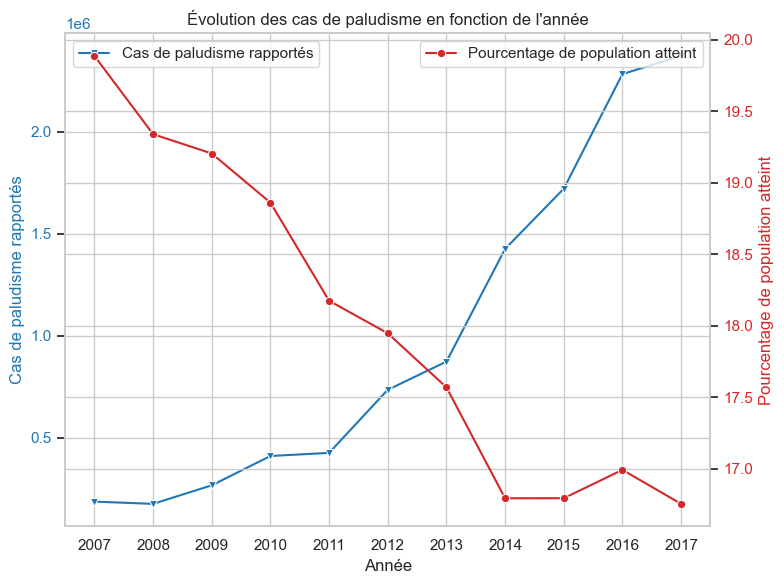

In [9]:

group1 = df.groupby('Year')[['Malaria cases reported', 'Pourcetage de population atteint']].mean().reset_index()

sns.set(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(8, 6))

# Tracé premier axe
color1 = 'tab:blue'
sns.lineplot(data=group1, x='Year', y='Malaria cases reported', marker='v', ax=ax1, color=color1, label='Cas de paludisme rapportés')
ax1.set_ylabel('Cas de paludisme rapportés', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Tracé deuxième axe
ax2 = ax1.twinx()
color2 = 'tab:red'
sns.lineplot(data=group1, x='Year', y='Pourcetage de population atteint', marker='o', ax=ax2, color=color2, label='Pourcentage de population atteint')
ax2.set_ylabel('Pourcentage de population atteint', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Ajouter toutes les années sur l'axe X
ax1.set_xticks(range(group1['Year'].min(), group1['Year'].max() + 1))

plt.title("Évolution des cas de paludisme en fonction de l'année")
ax1.set_xlabel("Année")

fig.tight_layout()
plt.show()




### La courbe bleue traduit l'évolution croissante du nombre de Cas de paludisme signalés en fonction de l'année
### La courbe en rouge traduit du taux des personnes nouvellement contaminé 

# <span style='color:red;'> INTERPRETATION</span>


## Le nombre de cas rapportés par année est cumulatif d'ou l'allure de la courbe qui est croissante
## Le taux de contamination chute dû au moyen et methode pratique mise en place par les gouvernement pour lutter contre le paludisme dans chaque pays

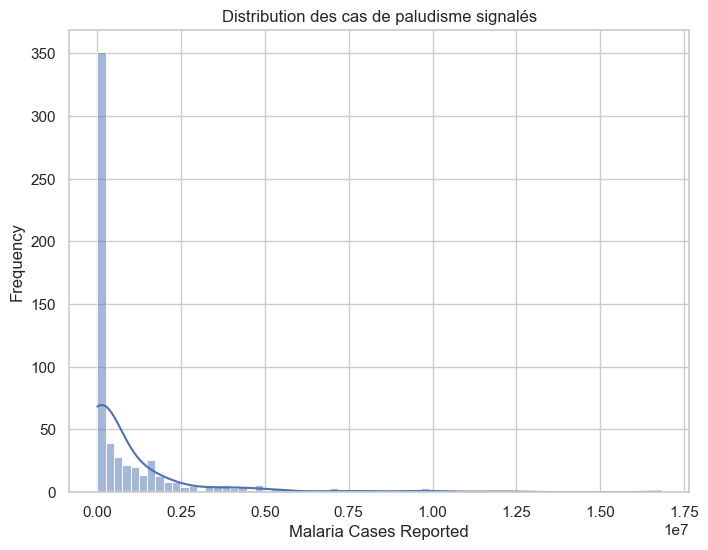

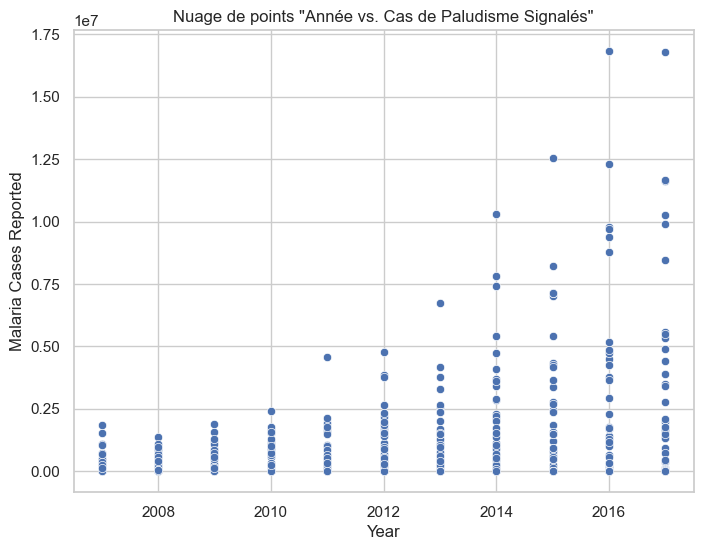

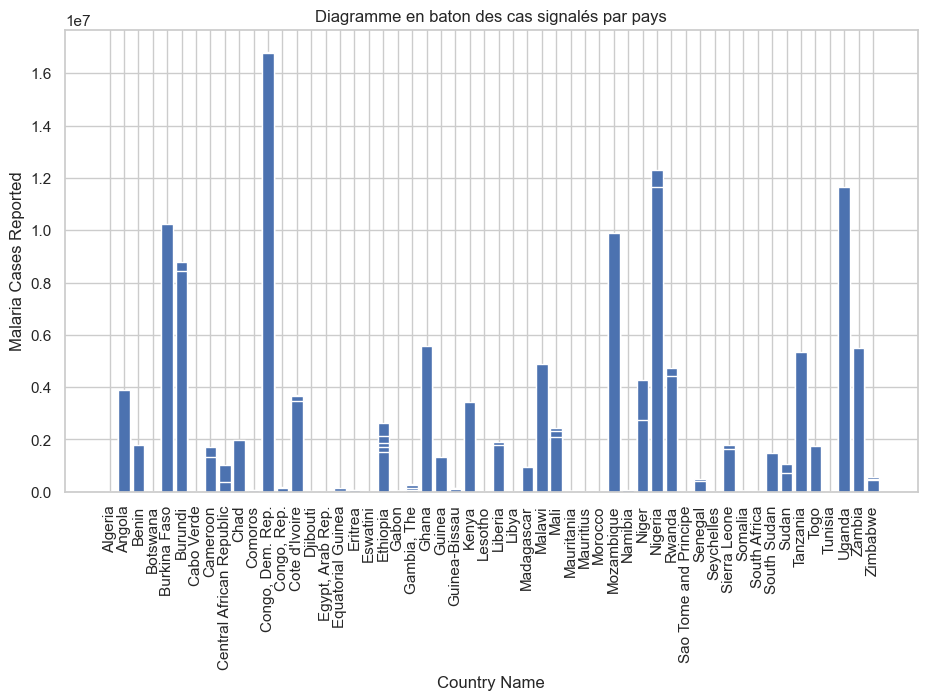

In [10]:
# Example 1: Histogram of 'Malaria cases reported'
plt.figure(figsize=(8, 6))
sns.histplot(df['Malaria cases reported'], kde=True)
plt.title('Distribution des cas de paludisme signalés')
plt.xlabel('Malaria Cases Reported')
plt.ylabel('Frequency')
plt.show()

# Example 2: Scatter plot of 'Year' vs. 'Malaria cases reported'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Year', y='Malaria cases reported', data=df)
plt.title('Nuage de points "Année vs. Cas de Paludisme Signalés"')
plt.xlabel('Year')
plt.ylabel('Malaria Cases Reported')
plt.show()


# Example 3: Box plot of 'Malaria cases reported' grouped by 'Country Name'
plt.figure(figsize=(11, 6))

plt.bar(df['Country Name'], height=df['Malaria cases reported'])
plt.title('Diagramme en baton des cas signalés par pays')
plt.xlabel('Country Name')
plt.ylabel('Malaria Cases Reported')
plt.xticks(rotation=90)

plt.show()

# <span style='color:orange'> Analyse</span>
## <span style='color:green'> Graphe 1</span> 
### La majorité des pays rapportent peu de cas de paludisme.Quelques pays seulement ont des millions de cas, ce qui crée une distribution très déséquilibrée (fortement asymétrique à droite).

## <span style='color:green'> Graphe 2</span> 
### Après 2010, plusieurs pays montrent une augmentation importante du nombre de cas.

## <span style='color:green'> Graphe 3</span> 
### Peu de pays concentrent la grande majorité des cas (notamment République Démocratique du Congo, Nigeria, Mozambique).Beaucoup de pays rapportent très peu de cas.

# <span style='color:orange'> Interprétation</span>
### La distribution des cas de paludisme est très inégale : la plupart des pays ont peu de cas, mais quelques-uns sont très touchés.
### Sur le temps, certains pays ont connu une aggravation du nombre de cas.
### En termes géographiques, l'Afrique centrale et de l'ouest semblent être les zones les plus affectées.

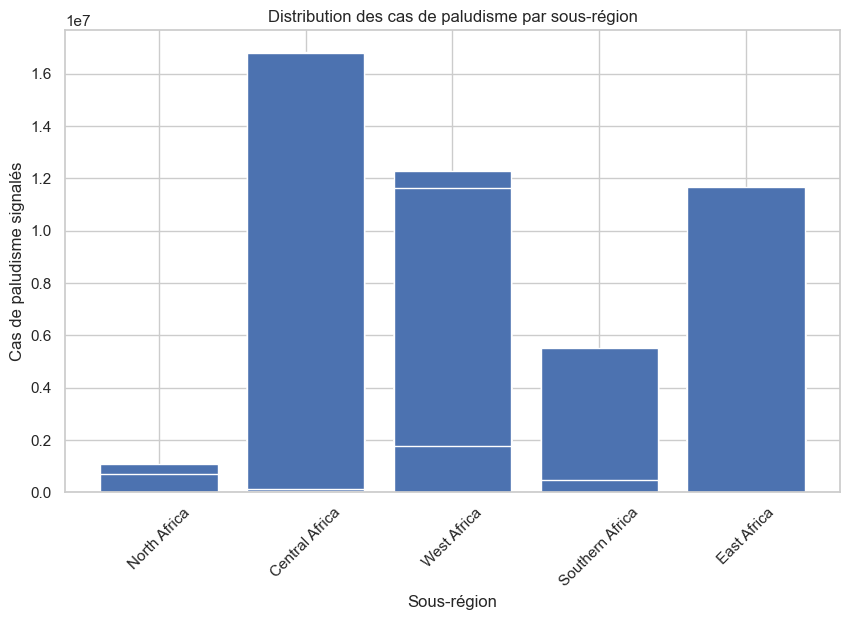

In [11]:
plt.figure(figsize=(10, 6))
plt.bar(df['Sous region'], height=df['Malaria cases reported'] ) 
plt.title('Distribution des cas de paludisme par sous-région')
plt.xlabel('Sous-région')
plt.ylabel('Cas de paludisme signalés')
plt.xticks(rotation=45)
plt.show()

# <span style='color:orange'> Analyse</span>
### L’Afrique centrale enregistre le plus grand nombre de cas de paludisme, suivie de l’Afrique de l’Ouest et de l’Est, tandis que l’Afrique du Nord est très peu touchée.
# <span style='color:orange'> Interprétation</span>

### Le paludisme touche surtout les régions d’Afrique subsaharienne, ce qui montre où les efforts de prévention et de traitement doivent être renforcés en priorité.

# <span style='color: red'>Quels sont alors les facteurs agissant sur la contamination ?</span>

<Axes: >

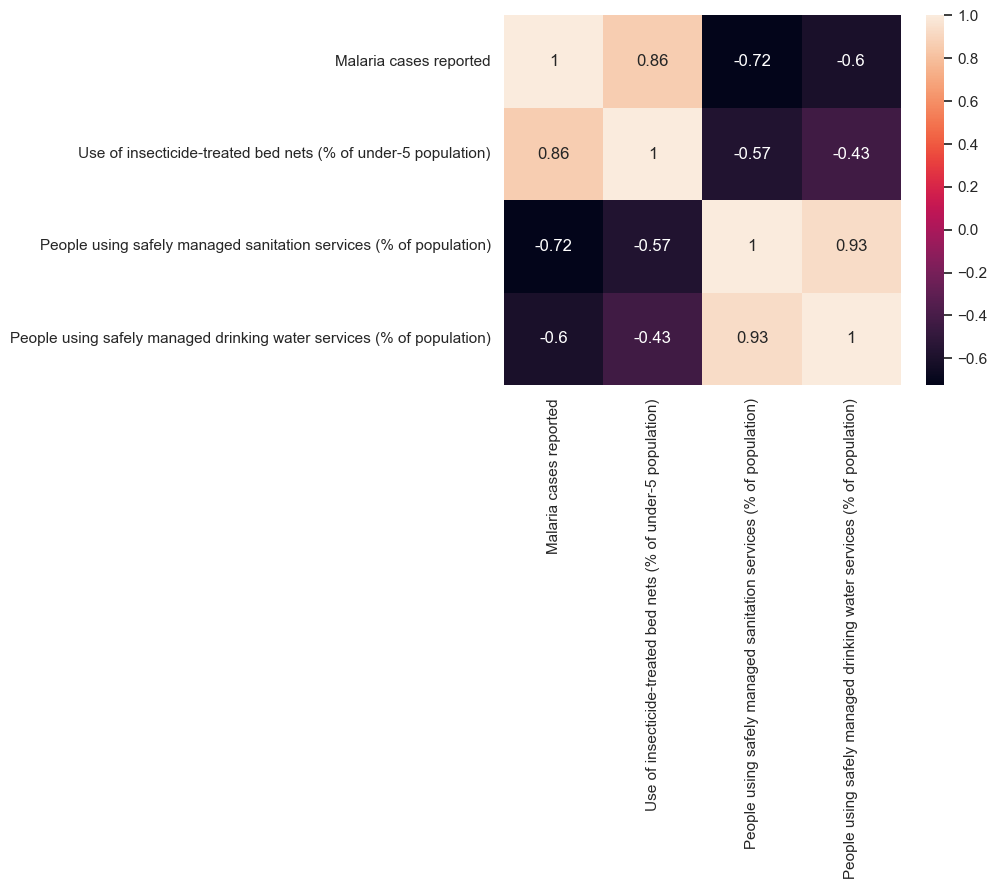

In [12]:
# Agréger les données par année
col_imp=['Malaria cases reported','Use of insecticide-treated bed nets (% of under-5 population)','People using safely managed sanitation services (% of population)','People using safely managed drinking water services (% of population)']
agg_df = df.groupby('Sous region')[col_imp].mean().reset_index()

# Calculer la corrélation
correlation_data = agg_df[col_imp].corr()
sns.heatmap(correlation_data,annot=True)





# <span style='color:orange'> Analyse</span>
### Le nombre de cas de paludisme augmente dans les zones où l’accès à l’eau potable, à l’assainissement et à la protection (moustiquaires) est insuffisant.

# <span style='color:orange'> Interprétation</span>
### Améliorer l’hygiène, l’accès à l’eau potable et la protection contre les moustiques (comme les moustiquaires) est essentiel pour réduire les cas de paludisme.

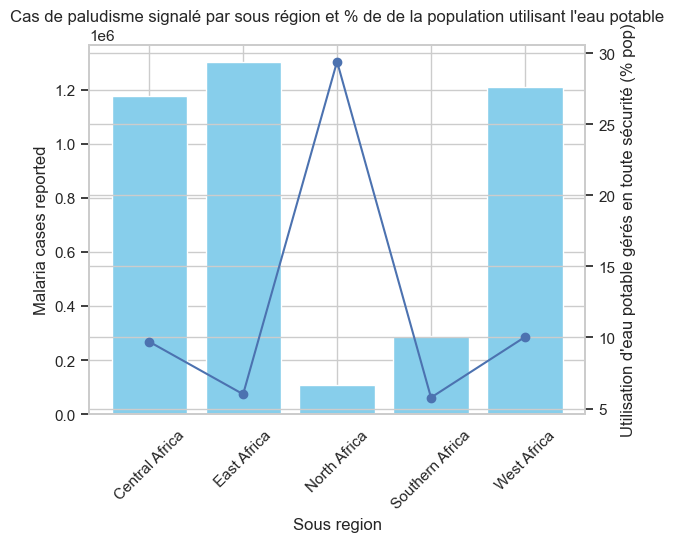

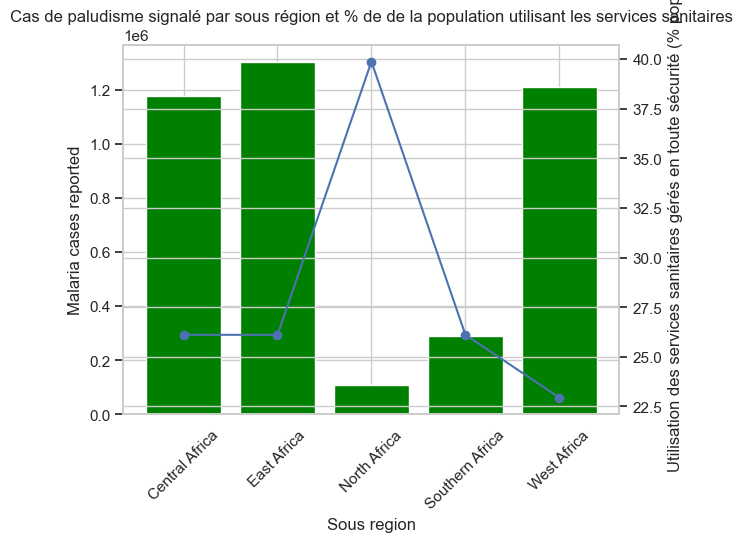

In [13]:
fig, ax1 = plt.subplots()
plt.xticks(rotation=45)
plt.title('Cas de paludisme signalé par sous région et % de de la population utilisant l\'eau potable')
ax1.bar(agg_df['Sous region'], agg_df['Malaria cases reported'], color='skyblue', label='Malaria cases reported')
ax1.set_xlabel('Sous region')
ax1.set_ylabel('Malaria cases reported')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(agg_df['Sous region'], agg_df['People using safely managed drinking water services (% of population)'], marker='o', label='People using safely managed drinking water services (% of population)')
ax2.set_ylabel('Utilisation d\'eau potable gérés en toute sécurité (% pop)')
ax2.tick_params(axis='y')


fig, ax1 = plt.subplots()
plt.xticks(rotation=45)
plt.title('Cas de paludisme signalé par sous région et % de de la population utilisant les services sanitaires')
ax1.bar(agg_df['Sous region'], agg_df['Malaria cases reported'], color='green', label='Malaria cases reported')
ax1.set_xlabel('Sous region')
ax1.set_ylabel('Malaria cases reported')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(agg_df['Sous region'], agg_df['People using safely managed sanitation services (% of population)'], marker='o', label='People using safely managed sanitation services (% of population)')
ax2.set_ylabel('Utilisation des services sanitaires gérés en toute sécurité (% pop)')
ax2.tick_params(axis='y')

plt.show()

# <span style='color:orange'> Analyse</span>
### Le nombre de cas de paludisme augmente dans les zones où l’accès à l’eau potable, à l’assainissement et à la protection (moustiquaires) est insuffisant selon les deux courbes sur les diagrammes .

# <span style='color:orange'> Interprétation</span>
### Pour faire reculer le paludisme, il est crucial d'améliorer les conditions d'hygiène, de garantir l'accès à l'eau potable et de renforcer la protection contre les moustiques.